# Mevsimsel Olmayan Zaman Serisi Tahminleri için Basit ARIMA Modeli

Bu zorluktaki hedefimiz, zaman serisi analizinin temel kavramlarını tek boyutlu verilere uygulamaktır

Bu zorluklarda şu adımları izleyeceğiz:
1. verileri yükleme ve görselleştirme;
2. modellerimizi eğitme ve tahminler yapma;

##  1. Veri Yükleme
Zorlukta kullanacağımız zaman serisini yükleyerek başlayalım. Veri setini CSV dosyası olarak indirmek için aşağıdaki satırı çalıştırın, ardından CSV'yi bir DataFrame'e yükleyin.

In [1]:
!curl https://d32aokrjazspmn.cloudfront.net/materials/www_usage.csv > data/www_usage.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   377  100   377    0     0   2925      0 --:--:-- --:--:-- --:--:--  2945


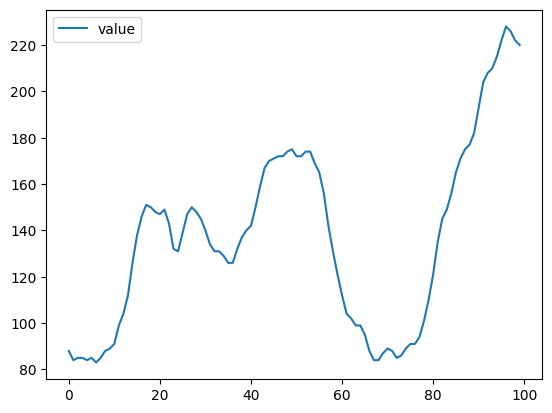

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/www_usage.csv', names=['value'], header=0)
y = df.value

df.plot();

Bu soyut zaman serisi mevsimsel görünmüyor, ancak artan bir trend ve bir şekilde "yapışkan" (yani biraz oto-regresif) özellikler gösteriyor. Bu nedenle Oto-Regresif Hareketli Ortalama (ARIMA) modelleri için iyi bir aday olabilir.

## 2. ARIMA Modeli Oluşturma
ARIMA modelleri (Oto Regresif Entegre Hareketli Ortalama) sayesinde verileri tahmin etmeye çalışacağız.

Bunun için şunları yapmamız gerekecek:
1. zaman serisini nasıl durağanlaştırılacağını bulma (ARIMA'daki I)
2. oto-regresif (AR) kısmını bulma
3. hareketli ortalama (MA) kısmını bulma
4. Uydurma
5. Performansı değerlendirme

### Adım 1 - Durağanlığı Sağlama

ARIMA modelleri yalnızca "durağan" zaman serilerine uygulanır.

👉 [`Genişletilmiş Dickey-Fuller testi`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) kullanarak durağanlığını kesin olarak kontrol edin, özellikle p-değerini

In [3]:
from statsmodels.tsa.stattools import adfuller

# ADF Testini uygulayalım
result = adfuller(y)

print(f'ADF İstatistiği: {result[0]}')
print(f'p-değeri: {result[1]}')

# Sonucu yorumlayalım
if result[1] < 0.05:
    print("Veri durağandır (H0 reddedildi).")
else:
    print("Veri durağan değildir (H0 reddedilemedi). Fark alma (differencing) gerekiyor.")

ADF İstatistiği: -2.464239717203369
p-değeri: 0.12441935447109442
Veri durağan değildir (H0 reddedilemedi). Fark alma (differencing) gerekiyor.


Durağanlıkta %95 güvenilirlik için p-değeri 0.05'ten küçük olmalıdır.
P-değeri 0.05'ten büyükse, boş hipotezi reddedemeriz (boş hipotez = "süreç durağan değildir").

Zaman serisi durağan değilse, **farklaştırma** yoluyla durağanlaştırılması gerekir.
- Bu, her değer ile bir önceki değer arasındaki farkı almak anlamına gelir (*birinci fark*).
- *İkinci fark* istiyorsanız, farklaştırılmış seri üzerinde işlemi tekrarlayın, vb...

👉 Durağan hale getirmek için ihtiyacımız olan minimum farklaştırma sırasını bulun (görselleştirmek için eğrileri çizin ve emin olmak için adfuller p-değerlerini yazdırın)

<details>
    <summary>İpucu</summary>

`pd.Series.diff`
</details>

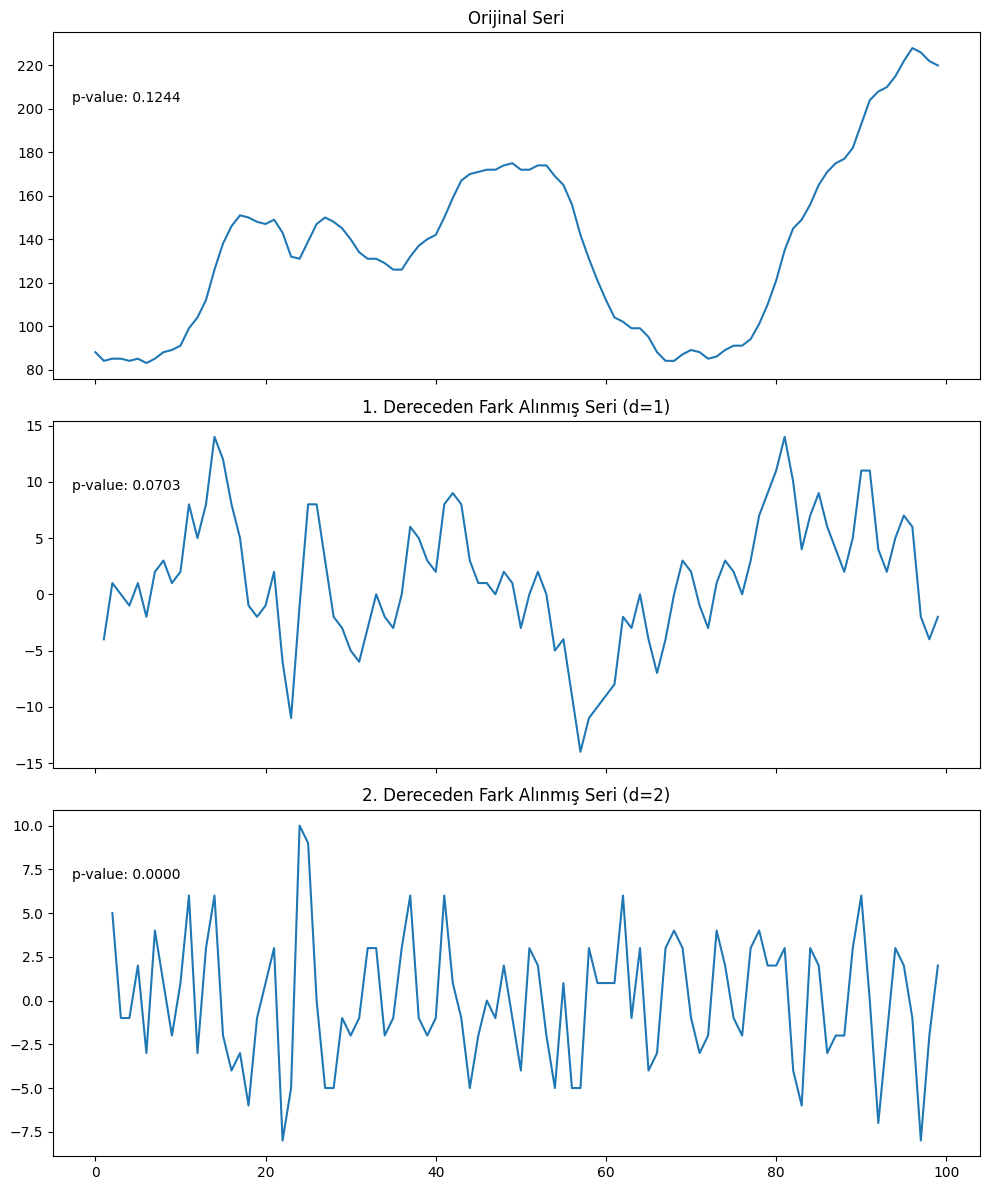

1. Fark p-değeri: 0.07026846015272728
2. Fark p-değeri: 2.8434287555470966e-17


In [4]:
import numpy as np

# 1. ve 2. Dereceden Farkları Hesaplayalım
y_diff1 = y.diff().dropna()
y_diff2 = y_diff1.diff().dropna()

# ADF Testlerini Yapalım
result1 = adfuller(y_diff1)
result2 = adfuller(y_diff2)

# Görselleştirme
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Orijinal Seri
axes[0].plot(y); axes[0].set_title('Orijinal Seri')
axes[0].text(0.02, 0.8, f'p-value: {result[1]:.4f}', transform=axes[0].transAxes)

# 1. Fark (d=1)
axes[1].plot(y_diff1); axes[1].set_title('1. Dereceden Fark Alınmış Seri (d=1)')
axes[1].text(0.02, 0.8, f'p-value: {result1[1]:.4f}', transform=axes[1].transAxes)

# 2. Fark (d=2)
axes[2].plot(y_diff2); axes[2].set_title('2. Dereceden Fark Alınmış Seri (d=2)')
axes[2].text(0.02, 0.8, f'p-value: {result2[1]:.4f}', transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

print(f"1. Fark p-değeri: {result1[1]}")
print(f"2. Fark p-değeri: {result2[1]}")

Burada bir ve iki fark sırası arasında yakın bir durumumuz var. Zaman serilerini fazla farklaştırmak ARIMA modellerinizin performansını da düşürebilir. Daha yakından bakalım:

👉 1. ve 2. fark sırası için otokorelasyon grafiğini ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) çizin.

(💡Profesyonel ipucu: Her statsmodels grafiği örneklemesinin sonuna `;` ekleyerek veya `plt.show()` çağırarak statsmodels grafiklerinin çoğaltılmasından kaçının)

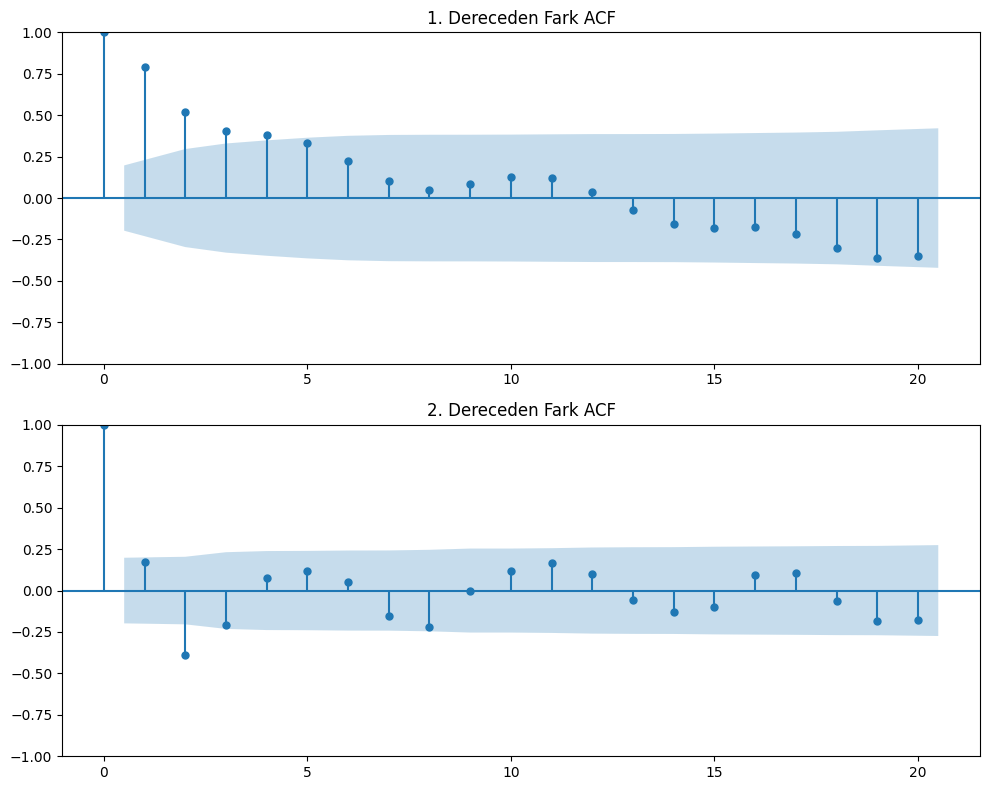

In [5]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# 1. Dereceden Fark (d=1) için ACF
plot_acf(y_diff1, ax=axes[0], title="1. Dereceden Fark ACF")

# 2. Dereceden Fark (d=2) için ACF
plot_acf(y_diff2, ax=axes[1], title="2. Dereceden Fark ACF")

plt.tight_layout()
plt.show()

"İkinci sıra fark" otokorelasyon grafiğimizde, 1 numaralı gecikme katsayısı 0'a yakın, ikincisi ise negatif bölgeye kadar uzanıyor. Bu, seriyi aşırı farklaştırdığımızı gösterebilir. (Unutmayın: her zaman 1'e eşit olan 0 numaralı gecikmeyİ hiçbir zaman umursamayız)

👉 (Geçici olarak) yalnızca bir fark sırasını tutalım ve bu seriyi `y_diff` olarak adlandıralım (daha sonra her zaman daha fazla fark deneyebiliriz)

In [6]:
y_diff = y.diff().dropna()

Az önce ARIMA'daki "I" terimini bulduk: durağan olmadan önce 1-fark için `d = 1` ("I", "entegrasyon"u ifade eder, "d" farklaştırma için...)

### Adım 2 - AR sırası (p) ve MA sırasını (q) seçin

#### MA($\color{blue}{q}$) = $Y^{\color{green}{(d)}}$'nin $\color{blue}{ACF}$'inin kesildiği gecikme sayısı

MA sırası (`q`), `y_diff`'e uygulanan otokorelasyon grafiğine ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) bakılarak bulunabilir.

👉 `q`'yu belirleyin

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

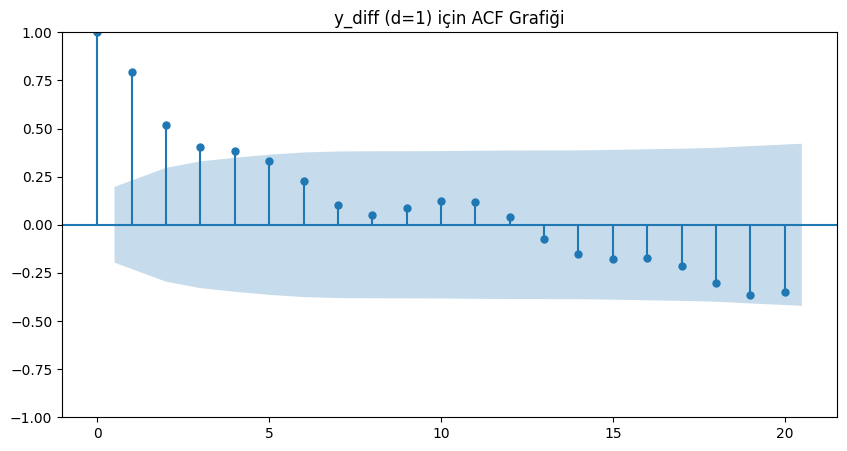

In [8]:
# Sadece d=1 üzerinden ACF grafiğine odaklanalım
y_diff = y.diff().dropna()

fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(y_diff, ax=ax, title="y_diff (d=1) için ACF Grafiği")
plt.show()

Modelimizi uydurma için değerlendirmemiz gereken maksimum değer q = 4 gibi görünüyor. Ancak, Otomatik-ARIMA kullanacak olsaydık (bu konuda daha sonra ayrıntılı bilgi), q=2 kullanmanın ideal sonuçlar verdiğini görürdük, bu nedenle başlangıçta q=2 ayarlamayı deneyelim.

Şüpheniz olduğunda, Y'yi yeterince açıklayan daha basit modeli seçin.

#### AR($\color{red}{p}$) = $Y^{\color{green}{(d)}}$'nin $\color{red}{PACF}$'inin kesildiği gecikme sayısı

AR sırası (`p`), `y_diff`'e uygulanan **k**ısmi otokorelasyon grafiği [`plot_pacf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_pacf.html) incelenerek bulunabilir.

(Kısmi otokorelasyon, ara gecikmelerin katkılarını hariç tuttuktan sonra seri ile gecikmesi arasındaki korelasyon olarak düşünülebilir. Yani, PACF bir şekilde bir gecikme ile seri arasındaki saf korelasyonu iletir)

👉 `p`'yi belirleyin

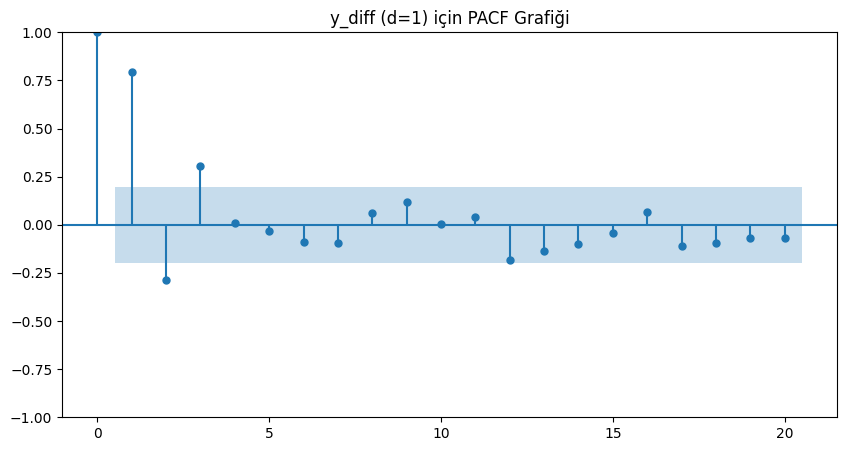

In [9]:
from statsmodels.graphics.tsaplots import plot_pacf

# y_diff (d=1) serisi üzerinden PACF çizimi
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(y_diff, ax=ax, title="y_diff (d=1) için PACF Grafiği")
plt.show()

İlk 3 gecikme terimi anlamlılık düzeyinin üstünde göründüğü için `p = 3` seçebiliriz, ancak daha basit bir model `p = 1` ile de gidebiliriz.

### Adım 3 - Modeli oluşturun

Artık ARIMA için `p`, `d` ve `q` değerlerini seçtiğinize göre,

👉 `statsmodels`'den `arima_model`'i oluşturun.
- modeli uydurur
- modeli yazdır (`.summary`)

In [10]:
from statsmodels.tsa.arima.model import ARIMA

# 1. Modeli tanımlayalım (p=1, d=1, q=2)
# Not: Veri setinin orijinal halini (y) veriyoruz, d=1 parametresi fark alma işlemini içeride yapar.
model = ARIMA(y, order=(1, 1, 2))

# 2. Modeli veriye uyduralım (Fit)
model_fit = model.fit()

# 3. Model özetini yazdıralım
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -254.126
Date:                Sat, 28 Mar 2026   AIC                            516.253
Time:                        15:07:30   BIC                            526.633
Sample:                             0   HQIC                           520.453
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6976      0.130      5.365      0.000       0.443       0.952
ma.L1          0.4551      0.169      2.699      0.007       0.125       0.786
ma.L2         -0.0664      0.157     -0.424      0.6

☝️ P-değerleriniz çok yüksekse, karşılık gelen AR veya SA katsayılarını azaltarak bu terimleri kaldırmayı deneyin.

[`AIC - Akaike Bilgi Kriteri`](https://medium.com/towardsdatascience/the-akaike-information-criterion-c20c8fd832f2) değerini en aza indirerek uyumunuzun genel performansını değerlendirebilirsiniz

(1,1,1) ARIMA modellerinin aşırı uydurmaya karşı daha az şansı olduğu (p-değerleri düşük kalır) ve diğer modellerden neredeyse benzer bir AIC puanı koruduğu görülüyor

## 3. Model performansını değerlendirin

👉 `plot_predict()` yöntemi ile model tahminlerinizi görselleştirin

- Yöntemin varsayılan parametrelerine, özellikle `dynamic` parametrelerine yakından bakın.
- Modelinizin gerçekte böyle iyi bir performansa sahip olacağını düşünüyor musunuz?

In [11]:
from statsmodels.graphics.tsaplots import plot_predict

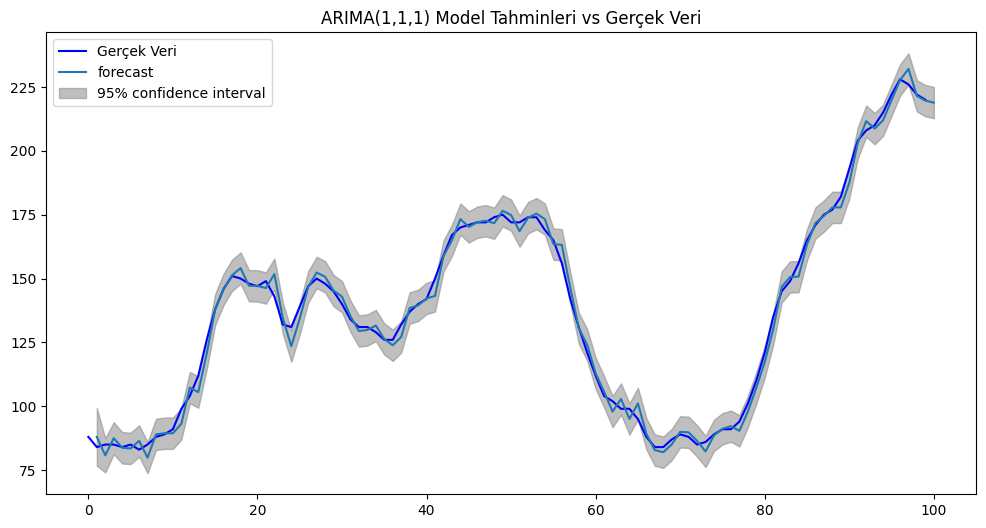

In [12]:
from statsmodels.graphics.tsaplots import plot_predict

# Modeli daha anlamlı olan (1, 1, 1) ile güncelleyelim
model_final = ARIMA(y, order=(1, 1, 1))
model_fit_final = model_final.fit()

# Tahminleri görselleştirelim
fig, ax = plt.subplots(figsize=(12, 6))
y.plot(ax=ax, label='Gerçek Veri', color='blue')

# Tahminleri çizdirme (start=1 fark alma nedeniyle 0. indeksi kaybederiz)
plot_predict(model_fit_final, start=1, end=100, ax=ax)

plt.title("ARIMA(1,1,1) Model Tahminleri vs Gerçek Veri")
plt.legend()
plt.show()

☝️ `dynamic=False`, `y_pred`'i tahmin etmek için mevcut tüm `y` değerlerini kullanır, bu da ARIMA tahminizin $y_t$'yi tahmin etmek için $y_{t-1}$'e kadar kullanmasını sağlar. Gerçekte, özellikle gelecekte birkaç aralığı tahmin etmek istiyorsanız tüm `y`'ye erişiminiz yoktur.

👉 Modelin yalnızca _85'e kadar verilere erişimi_ olan bir durumda _son 15 değeri_ tahmin eden bir tahmini çizmek için `dynamic=True` kullanmayı deneyin. Yani model:
- gerçek [1...85]'e dayalı olarak 86'yı tahmin eder
- sonra 86 için önceden tahmin ettiği değer _artı_ [1...85]'e dayalı olarak 87'yi tahmin eder
- vb...100'e kadar yinelemeli olarak

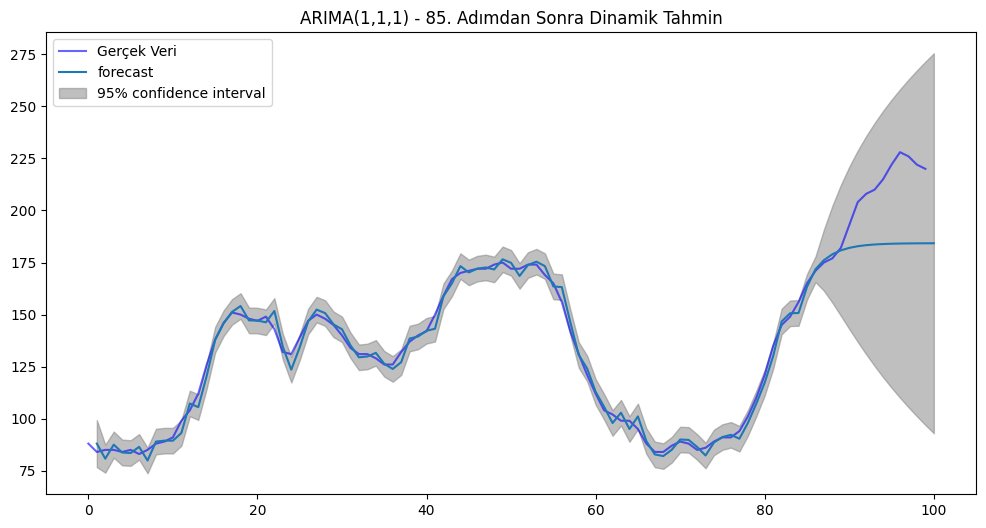

In [13]:
# ARIMA(1, 1, 1) modelini kurup eğitiyoruz
model_final = ARIMA(y, order=(1, 1, 1))
model_fit_final = model_final.fit()

# Görselleştirme
fig, ax = plt.subplots(figsize=(12, 6))

# Tüm gerçek veriyi çizelim
y.plot(ax=ax, label='Gerçek Veri', color='blue', alpha=0.6)

# 85. adımdan itibaren dinamik tahmini başlatalım
# dynamic=85 demek; 85'e kadar gerçek veriyi kullan, sonrasında kendi tahminlerine güven demektir.
plot_predict(model_fit_final, start=1, end=100, dynamic=85, ax=ax)

plt.title("ARIMA(1,1,1) - 85. Adımdan Sonra Dinamik Tahmin")
plt.legend(loc='upper left')
plt.show()

☝️ Bu hala _gerçek_ bir tahmin değil! Neden?

<details>
    <summary>Cevap</summary>

Modelimiz uyum aşamasında tüm `y_true` serisini "gördü"!
</details>

### 3.1 Örneklem Dışı Tahminler (gerçek "gelecek")

👉 Test seti için yalnızca son 15 veri noktasını tutarak bir eğitim-test bölümü oluşturun ve ARIMA'nızı yalnızca eğitim setinde eğitin.

In [14]:
# Veriyi bölelim: Son 15 veri testi, geri kalanı eğitimi temsil eder
train = y[:85]
test = y[85:]

# Modeli sadece eğitim (train) verisiyle kuralım
model_train = ARIMA(train, order=(1, 1, 1))
model_fit = model_train.fit()

# Özetle katsayıların anlamlılığını tekrar kontrol edebilirsin
# print(model_fit.summary())

👉 Şimdi 85. adımdayız ve geleceği hiç görmedik:
- Sonraki 15 veri noktasını (yani eğitim veri setinizin sonundan sonrasını) "tahmin etmek" için uydurduğunuz `arima` modelinde `get_forecast()` yöntemini kullanın

Yöntem `statsmodels`'den bir `PredictionResultsWrapper` nesnesi döndürür.

**💻 Bu sonucu `forecast_results` adlı bir değişkende saklayın.**

İlk başta gezinmek zordur, ancak işte bazı ipuçları:
- Tahminlerinizi `forecast_results.predicted_mean`'de bulabilirsiniz
- Güven aralıklarınız `forecast_results.conf_int()` tarafından verilir

In [15]:
# 1. 15 adım sonrasını tahmin edelim (Test setimizin uzunluğu kadar)
forecast_results = model_fit.get_forecast(steps=15)

# 2. Tahmin edilen ortalama değerleri (y_pred) alalım
forecast_mean = forecast_results.predicted_mean

# 3. %95 güven aralığı sınırlarını (alt ve üst) alalım
confidence_intervals = forecast_results.conf_int()

# Verilerin başlıklarını ve ilk birkaç tahminini görelim
print("--- Gelecek 15 Adım Tahmini ---")
print(forecast_mean.head())
print("\n--- Güven Aralıkları (Alt ve Üst Sınır) ---")
print(confidence_intervals.head())

--- Gelecek 15 Adım Tahmini ---
85    163.161121
86    167.885191
87    171.001581
88    173.057410
89    174.413606
Name: predicted_mean, dtype: float64

--- Güven Aralıkları (Alt ve Üst Sınır) ---
    lower value  upper value
85   156.929245   169.392997
86   153.134450   182.635933
87   147.668959   194.334203
88   141.542363   204.572457
89   135.260009   213.567204


👉 Tahmin edilen değerleri ve ayrıca %95 belirsizlik aralığının üst ve alt aralığını çizin

👉 Model performansını geçmişe göre daha iyi kavramak için önceki 85 `y` gerçek veri noktanızı da çizmeyi deneyin

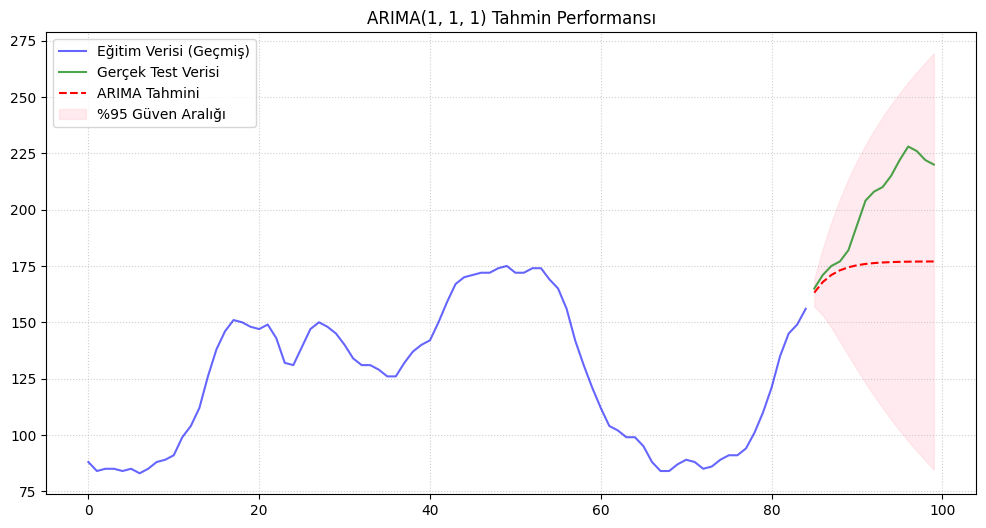

In [17]:
# 1. Tahminleri ve güven aralıklarını tekrar tanımlayalım (Hata almamak için)
y_pred = forecast_results.predicted_mean
conf_int = forecast_results.conf_int()

# 2. Görselleştirme
plt.figure(figsize=(12, 6))

# Eğitim verisi (0-85 arası)
plt.plot(train, label='Eğitim Verisi (Geçmiş)', color='blue', alpha=0.6)

# Test verisi (Gerçek 85-100 arası) - Bunu da ekleyelim ki farkı görelim!
plt.plot(test, label='Gerçek Test Verisi', color='green', alpha=0.7)

# Modelin Tahmini (85-100 arası)
plt.plot(y_pred, label='ARIMA Tahmini', color='red', linestyle='--')

# %95 Güven Aralığı (Pembe Bölge)
plt.fill_between(conf_int.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='%95 Güven Aralığı')

plt.title("ARIMA(1, 1, 1) Tahmin Performansı")
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### 3.2 %95 güven aralığınıza güvenebilir misiniz? (çıkarım koşulları)

👉 Hiçbir örüntü olmadığından emin olmak için artıkları `model.resid` çizin
- Normal dağılım
- Sıfır ortalama
- Tekdüze varyans
- Oto-regresif örüntü yok (isterseniz artıkları plot_acf yapabilirsiniz)

Not: artıklar `plot_predict(dynamic=False)`'daki gibi tüm verileri 'görerek' oluşturulur

Ayrıca, artıkların yaklaşık olarak normal dağılımda olup olmadığını görmek için artıkların bir histogramını veya KDE uyumunu çizmeyi deneyin.

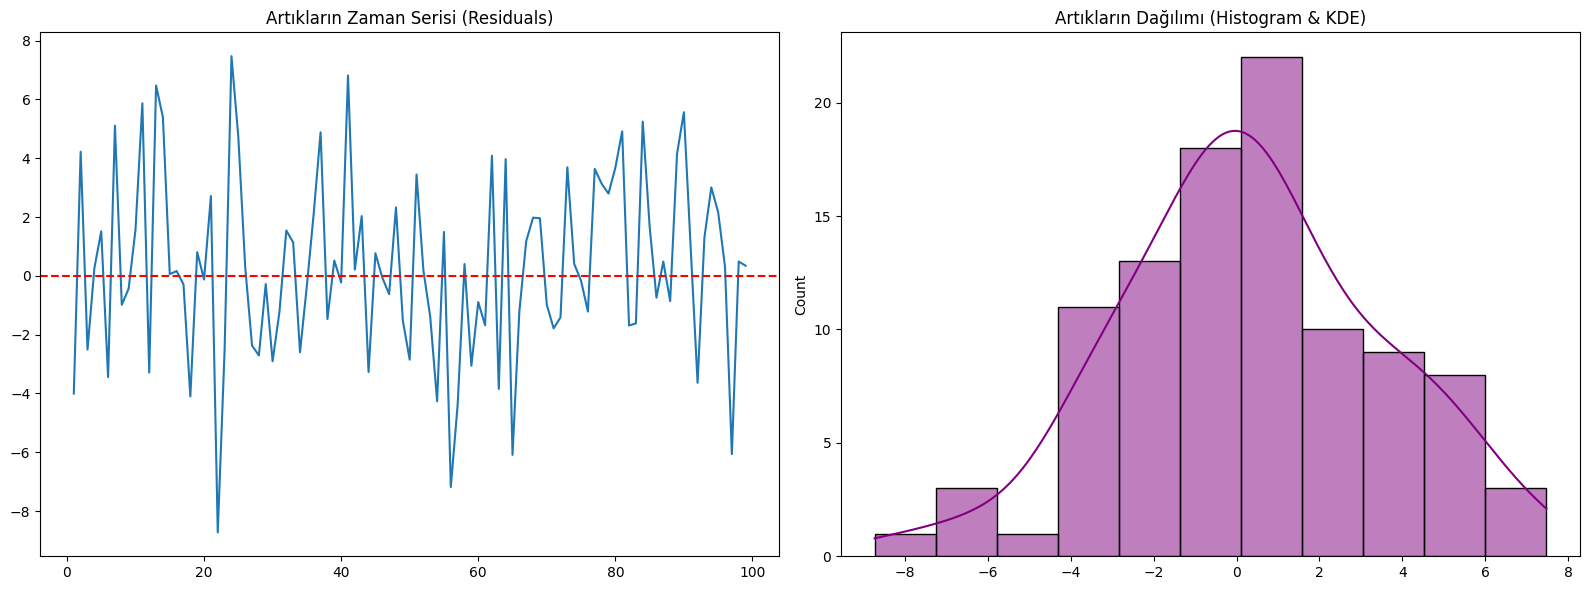

In [18]:
import scipy.stats as stats
import seaborn as sns

# Modelin artıklarını alalım (Tüm veri üzerinden eğitilmiş model_fit_final kullanıyoruz)
residuals = model_fit_final.resid[1:] # İlk değer fark alma nedeniyle 0 veya NaN olabilir, atlıyoruz

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Sol Grafik: Artıkların Zaman Serisi (Sıfır ortalama ve sabit varyans kontrolü)
ax[0].plot(residuals)
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_title('Artıkların Zaman Serisi (Residuals)')

# Sağ Grafik: Artıkların Dağılımı (Normal dağılım kontrolü)
sns.histplot(residuals, kde=True, ax=ax[1], color='purple')
ax[1].set_title('Artıkların Dağılımı (Histogram & KDE)')

plt.tight_layout()
plt.show()

## 3.3 Çapraz doğrulanmış performans ölçümleri

👉 Aşağıda zaman serileri için en yaygın performans ölçümleri yer almaktadır

In [19]:
import numpy as np
from statsmodels.tsa.stattools import acf

def forecast_accuracy(y_pred: pd.Series, y_true: pd.Series) -> float:

    mape = np.mean(np.abs(y_pred - y_true)/np.abs(y_true))  # Mean Absolute Percentage Error
    me = np.mean(y_pred - y_true)             # ME
    mae = np.mean(np.abs(y_pred - y_true))    # MAE
    mpe = np.mean((y_pred - y_true)/y_true)   # MPE
    rmse = np.mean((y_pred - y_true)**2)**.5  # RMSE
    corr = np.corrcoef(y_pred, y_true)[0,1]   # Correlation between the Actual and the Forecast
    mins = np.amin(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    maxs = np.amax(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(y_pred-y_true, fft=False)[1]                      # Lag 1 Autocorrelation of Error

    forecast = ({
        'mape':mape,
        'me':me,
        'mae': mae,
        'mpe': mpe,
        'rmse':rmse,
        'acf1':acf1,
        'corr':corr,
        'minmax':minmax
    })

    return forecast

👉 ARIMA hiper-parametrelerinizle oynayın ve tahmin performansınız üzerindeki etkisini görün

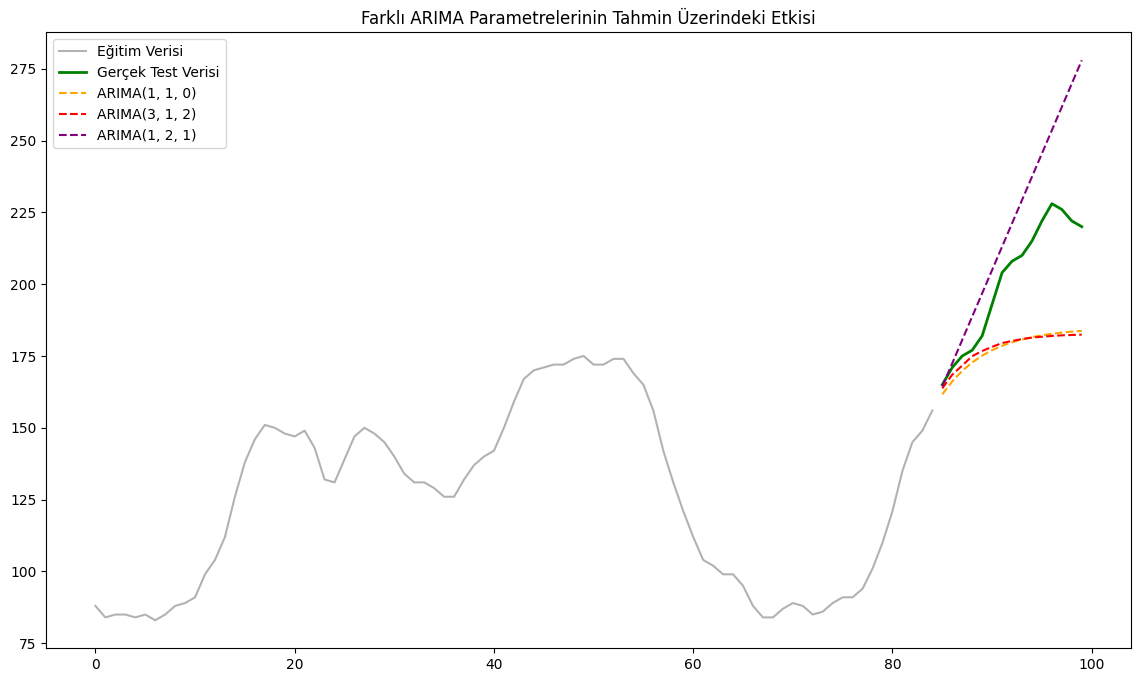

In [20]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Test etmek istediğimiz senaryolar
orders = [(1, 1, 0), (3, 1, 2), (1, 2, 1)]
plt.figure(figsize=(14, 8))
plt.plot(train, label='Eğitim Verisi', color='black', alpha=0.3)
plt.plot(test, label='Gerçek Test Verisi', color='green', linewidth=2)

colors = ['orange', 'red', 'purple']

for i, order in enumerate(orders):
    try:
        tmp_model = ARIMA(train, order=order).fit()
        tmp_forecast = tmp_model.get_forecast(steps=15).predicted_mean
        plt.plot(tmp_forecast, label=f'ARIMA{order}', color=colors[i], linestyle='--')
    except:
        print(f"Model {order} uydurulamadı.")

plt.title("Farklı ARIMA Parametrelerinin Tahmin Üzerindeki Etkisi")
plt.legend()
plt.show()

## 4 Izgara Arama

`pmdarima` kullanarak (p,d,q) için bir Izgara Arama çalıştırmayı deneyin. En azından şunları kullanın:
- `test='adf'`
- `trace=True`
- `error_action='ignore'`
- `suppress_warnings=True`

In [22]:
import pmdarima as pm

# Değişken ismini 'train' olarak düzelterek çalıştıralım
model_auto = pm.auto_arima(
    train,              # Az önce tanımladığımız y[:85]
    start_p=0, max_p=3, 
    start_q=0, max_q=3, 
    d=None,             # d'yi ADF testi ile model kendisi bulacak
    seasonal=False,     # Verimiz mevsimsel değildi
    test='adf',         # Durağanlık için ADF testini baz al
    trace=True,         # Adımları ekranda göster
    error_action='ignore', 
    suppress_warnings=True,
    stepwise=True       # Daha hızlı sonuç için akıllı arama yap
)

print("\n--- En İyi Model Özeti ---")
print(model_auto.summary())

/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=451.549, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=451.463, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=447.707, Time=0.06 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=449.662, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=447.705, Time=0.05 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=441.862, Time=0.08 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=439.922, Time=0.04 sec
 ARIMA(3,2,0)(0,0,0)[0] intercept   : AIC=441.881, Time=0.04 sec


/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.23 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=438.156, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=449.569, Time=0.01 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=440.125, Time=0.03 sec
 ARIMA(2,2,1)(0,0,0)[0]             : AIC=440.111, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=445.820, Time=0.02 sec


/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.12.9/envs/workintech/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/erdincuyar/.pyenv/versions/3.

 ARIMA(3,2,1)(0,0,0)[0]             : AIC=inf, Time=0.17 sec

Best model:  ARIMA(2,2,0)(0,0,0)[0]          
Total fit time: 0.871 seconds

--- En İyi Model Özeti ---
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   85
Model:               SARIMAX(2, 2, 0)   Log Likelihood                -216.078
Date:                Sat, 28 Mar 2026   AIC                            438.156
Time:                        15:11:38   BIC                            445.412
Sample:                             0   HQIC                           441.071
                                 - 85                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2328      0.108      2.160 

## (İsteğe bağlı) Modelinizin Performansını Çapraz Doğrulayın

Pratikte, sonuçlar ve Izgara Arama her zaman çapraz doğrulanmalıdır:

Modelinizin performansını gerçekten değerlendirmek ve çapraz doğrulamadan sonra en iyi hiperparametreleri bulmak için bitişik K-katlar oluşturmak amacıyla [`sklearn.model_selection.TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) kullanmaktan çekinmeyin.

<img src='https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_013.png'>

**ARIMA - TimeSeriesSplit + Izgara Arama kullanarak Çapraz Doğrulama**

In [ ]:
# YOUR CODE HERE

In [ ]:
df.sort_values('AIC').groupby('(p, d, q)').mean()['AIC'].sort_values()

☝️ İlk model seçimimiz (1, 1, 2) çok da kötü değil!
Veri seti (100 veri noktası) gerçekte herhangi bir şeyi çapraz doğrulamak için çok küçük olduğuna dikkat edin!